# Analyze Baselines

In [39]:
from pathlib import Path
import os
import json
from itertools import product

import pandas as pd

In [40]:
from temp import (
    mis_metrics,
    plot_mis_predictions
)

## Load Original Flows

In [41]:
# Configuration
dataset = "darpa2000"
scenario = "s1_inside"

In [42]:
df = pd.read_csv(
    f"../data/interim/{dataset}/{scenario}/flows_labeled/all_flows_labeled.csv"
)

df = df.sort_values("start_time").reset_index(drop=True)
df['t_rel'] = df['start_time'] - df['start_time'].min()

In [43]:
phase_bounds = (
    df[df['phase'] > 0]
    .groupby('phase')['t_rel']
    .agg(['min', 'max'])
)

phase_start = phase_bounds['min'].to_dict()
phase_end   = phase_bounds['max'].to_dict()

In [44]:
phase_bounds

,min,max
phase,,
1,1799.665435,1824.341042
2,2790.877254,3333.974143
3,4294.134775,4402.837414
4,5305.272464,5357.444592
5,7478.960660,8383.254878


## Temp Plots and Custom Metrics

In [45]:
models = [
    "multi_class",
    "ensemble",
]

features_opts = [
    "all",
    "dpl",
]

window_sizes = [
    10, 
    50, 
    100
]

dataset_variant_opts = [
    "original",
    "up", 
    "down",
]

class_weight_opts = [
    "no_class_weights", 
    # "class_weights"
]

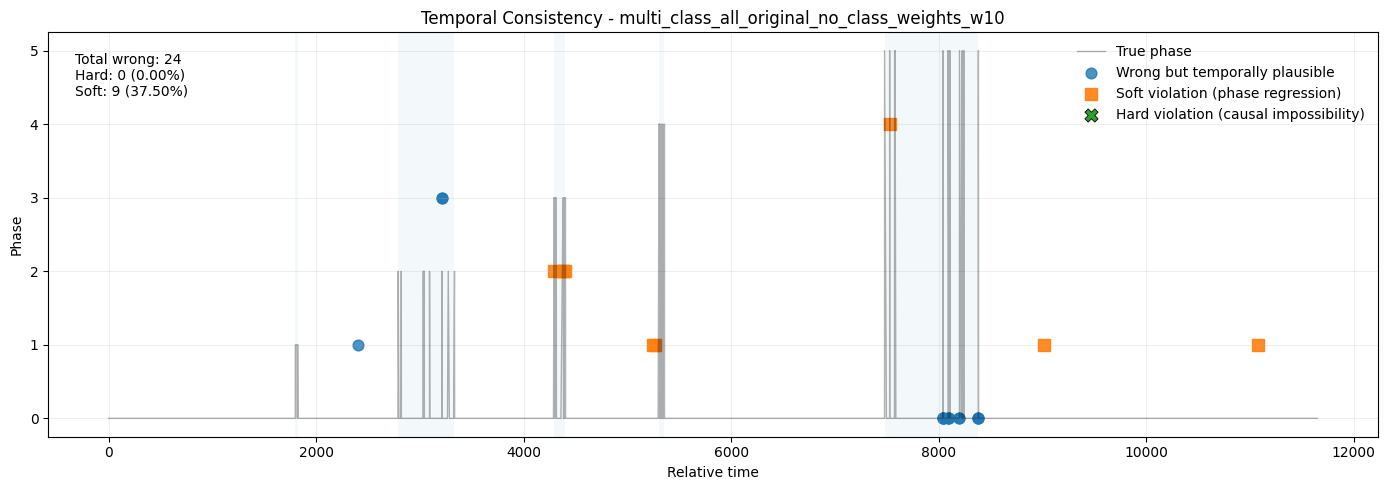

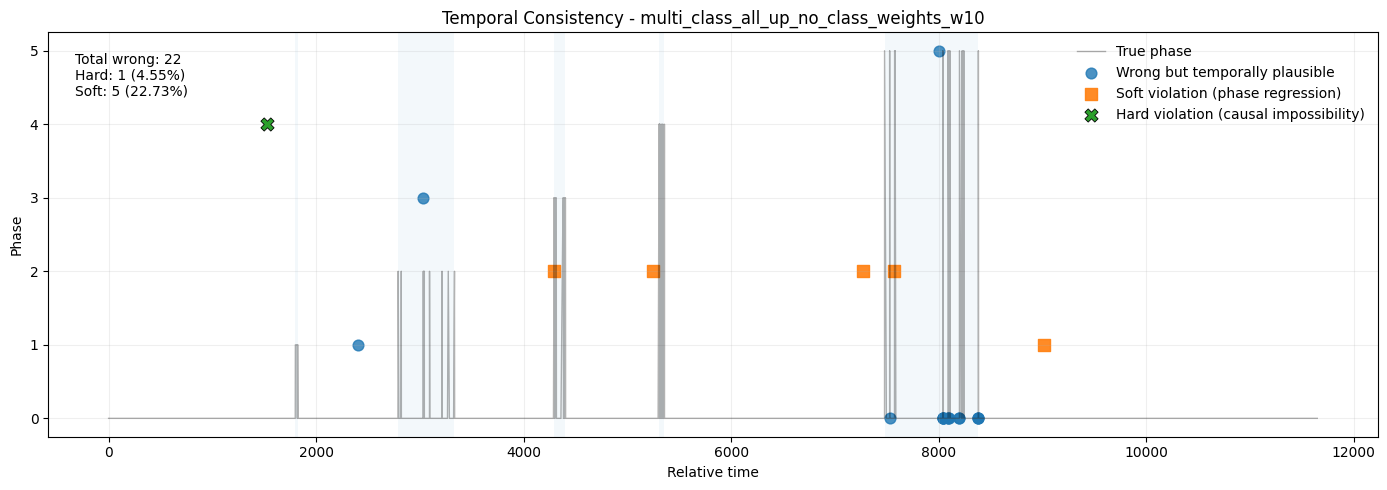

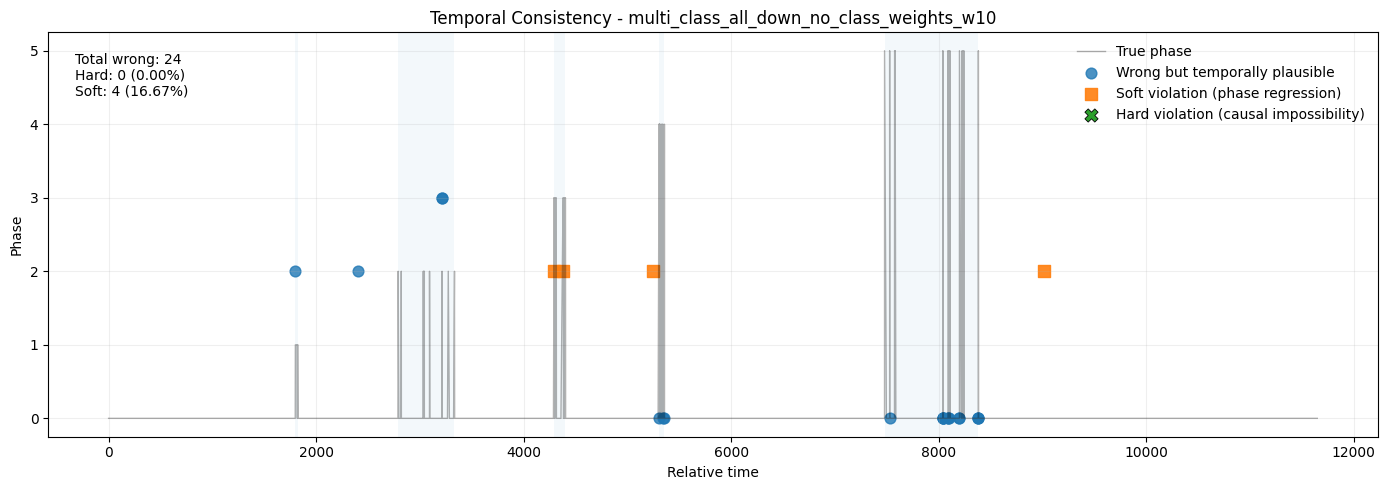

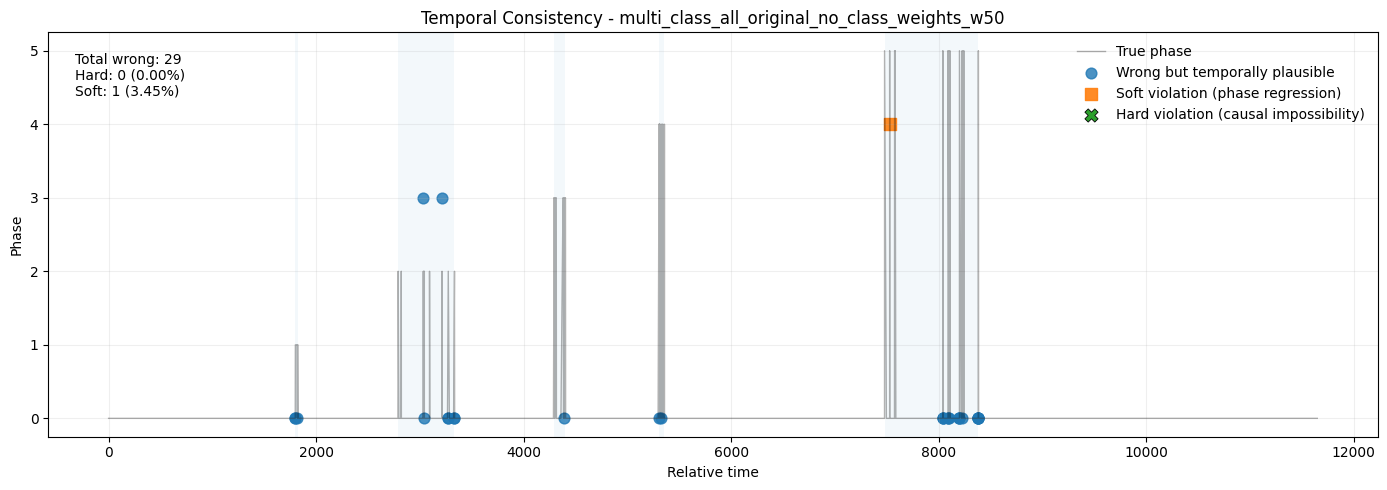

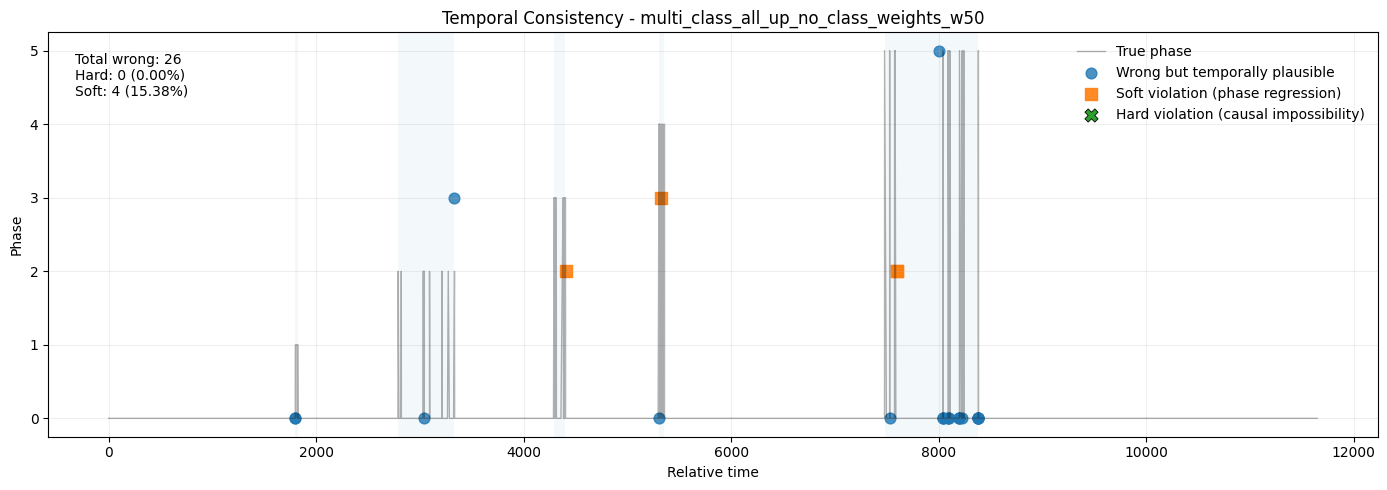

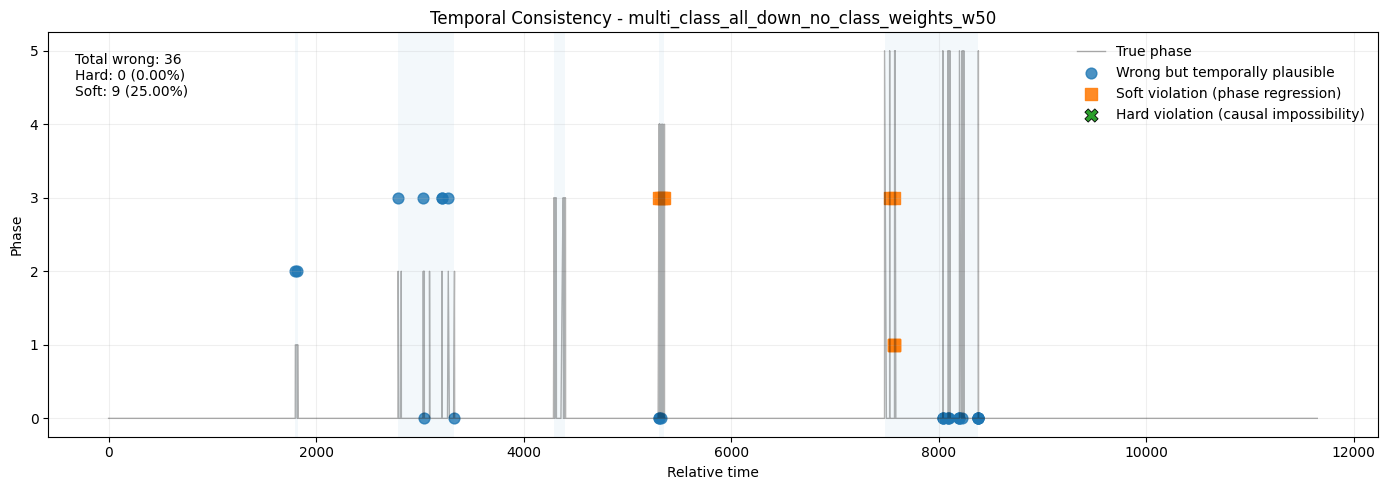

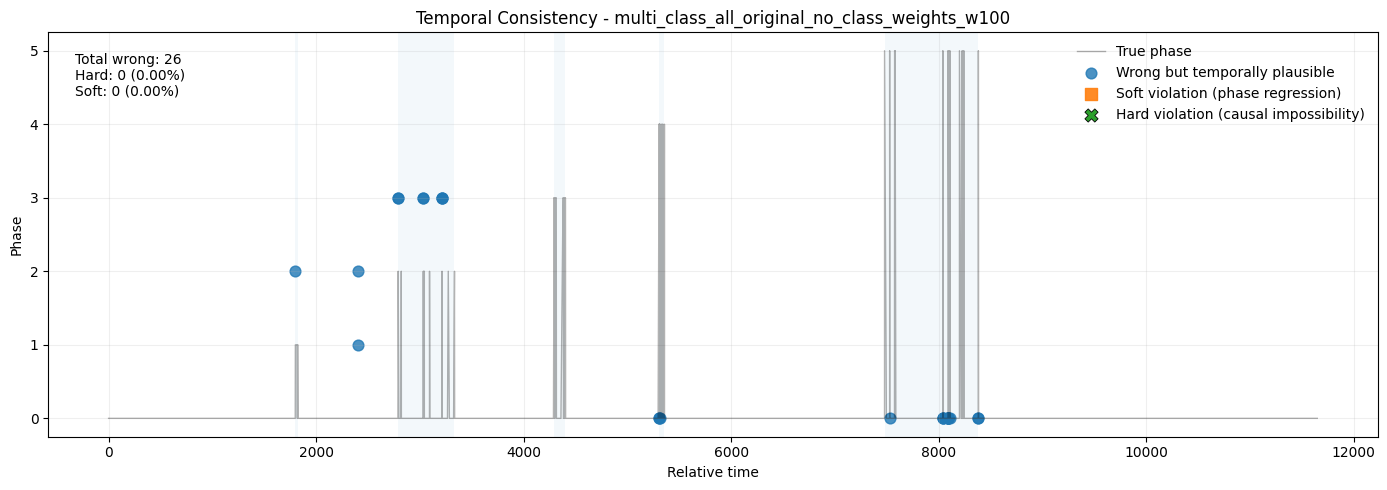

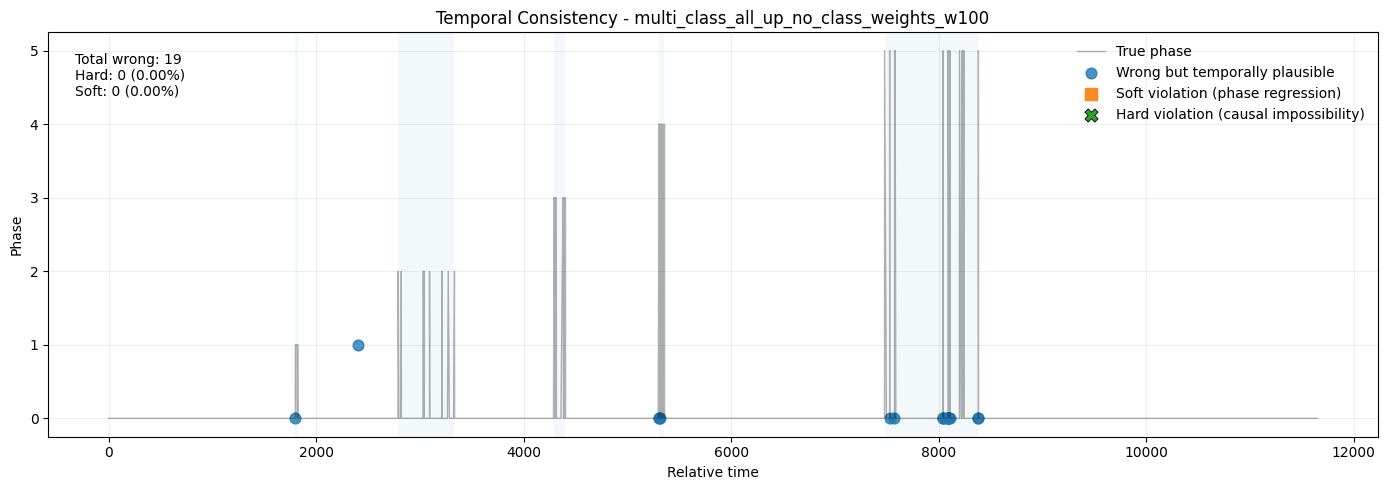

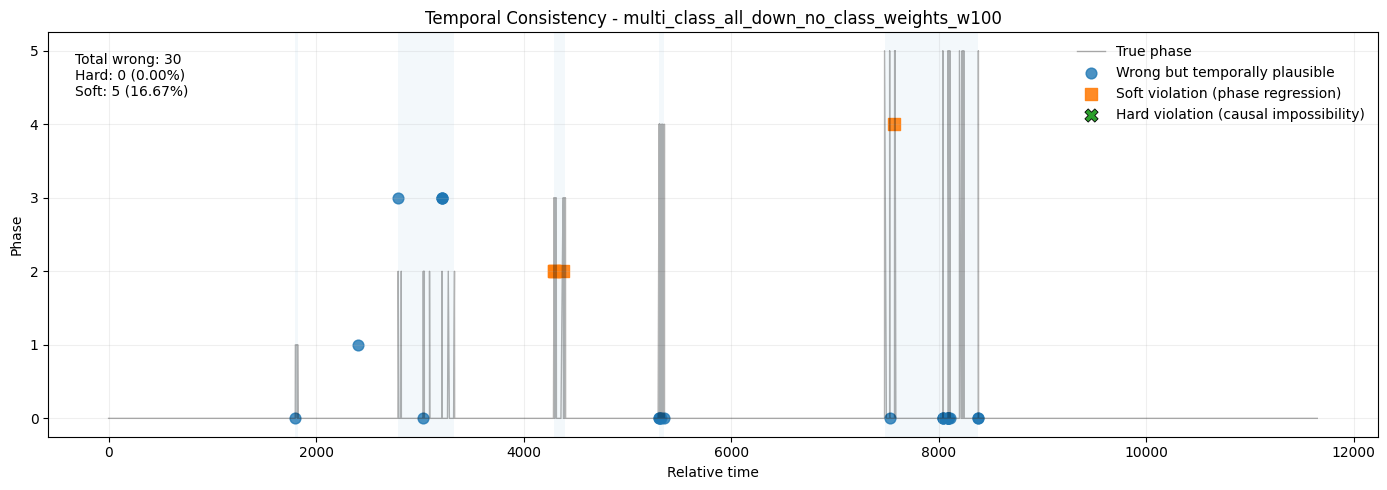

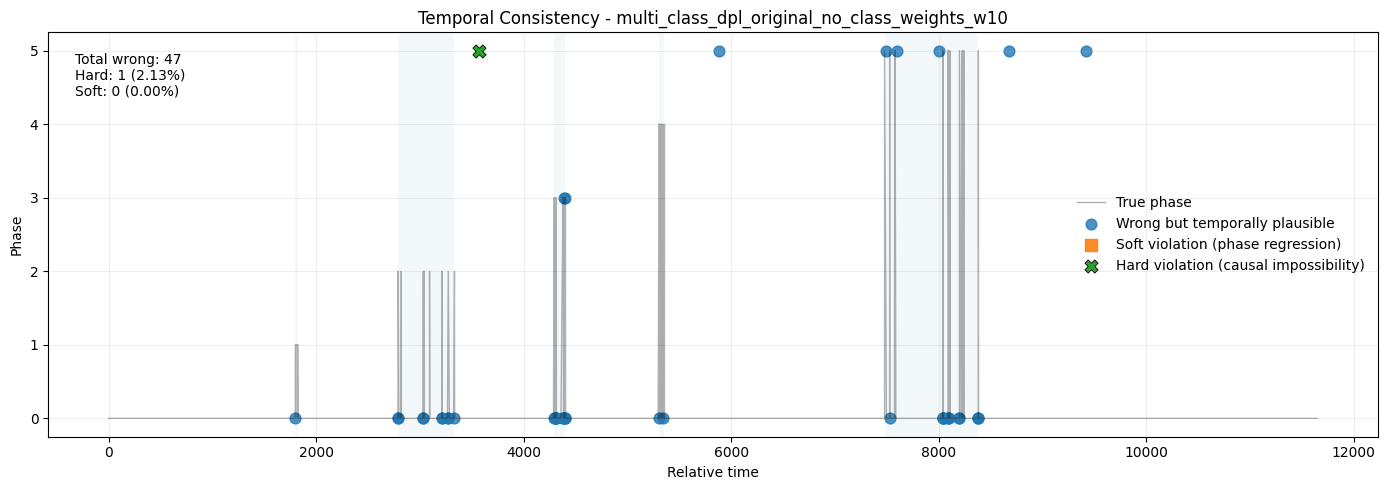

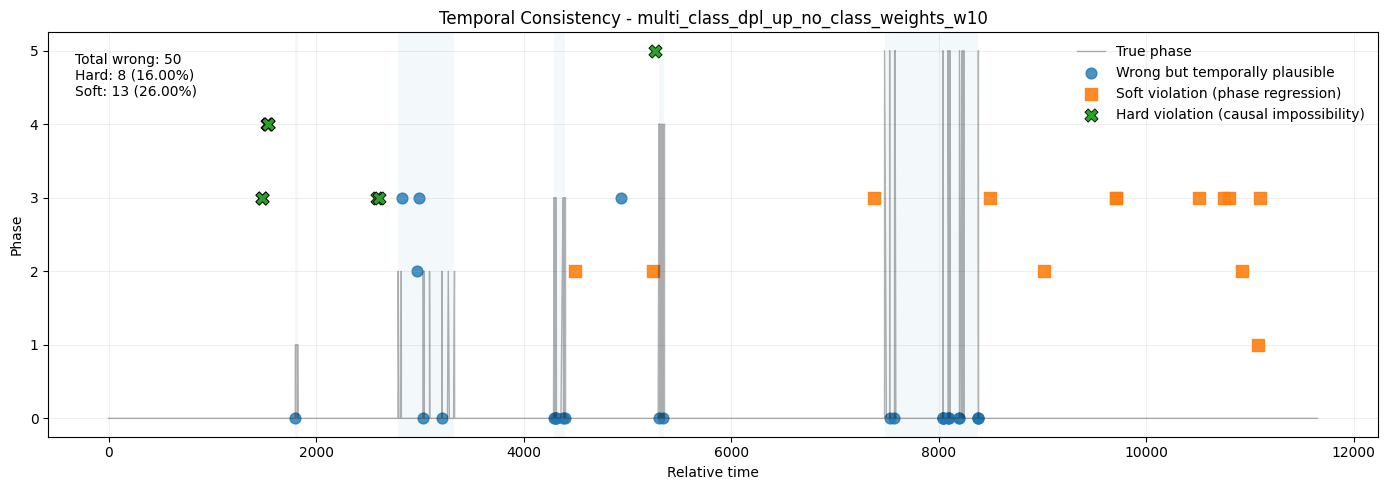

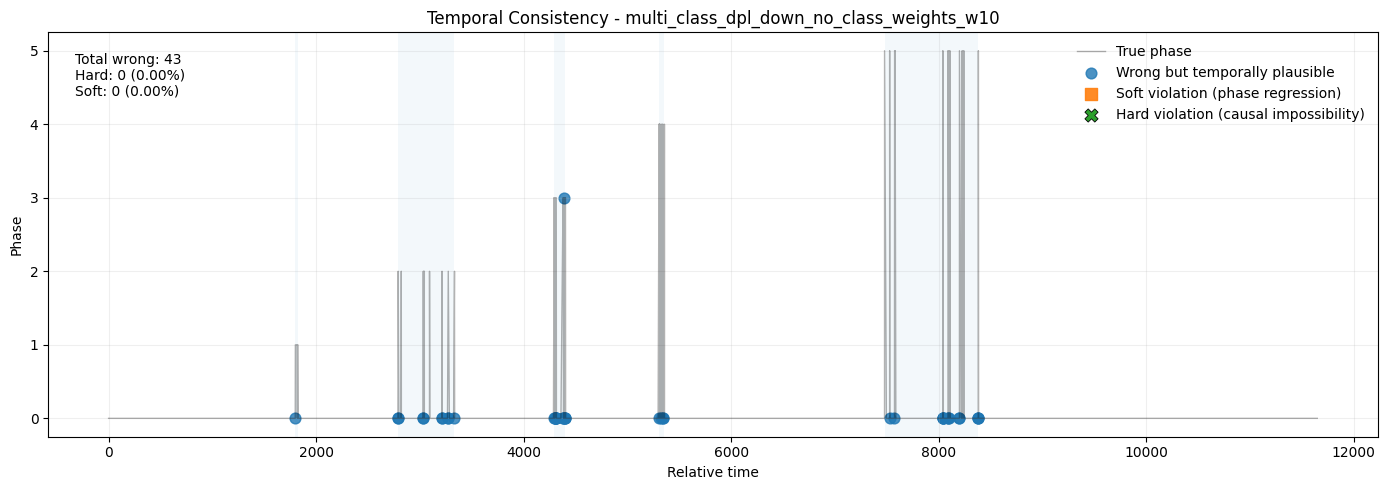

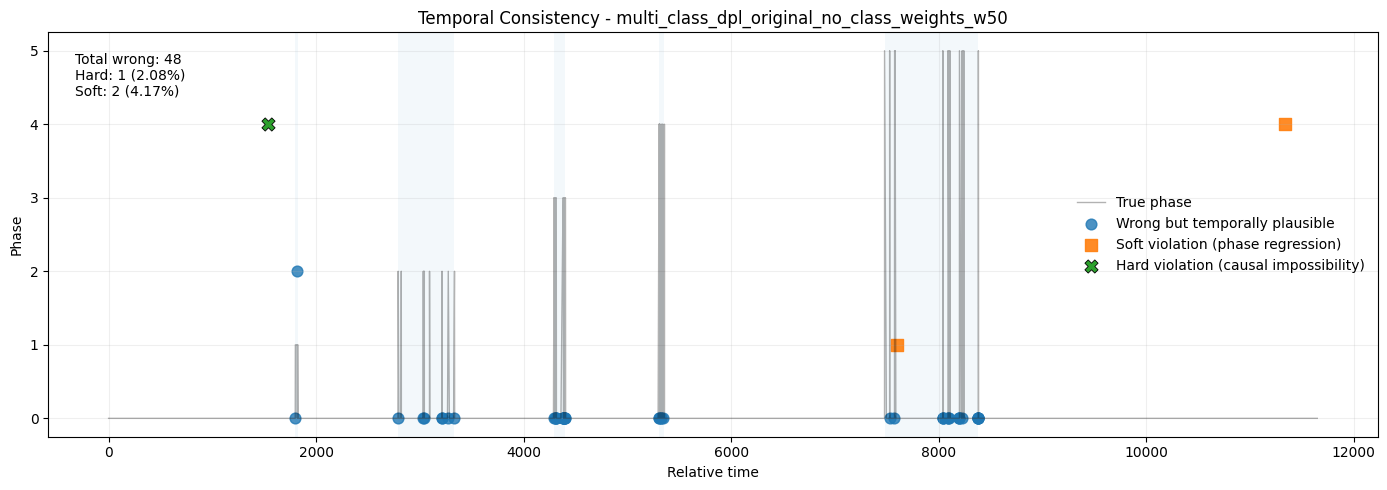

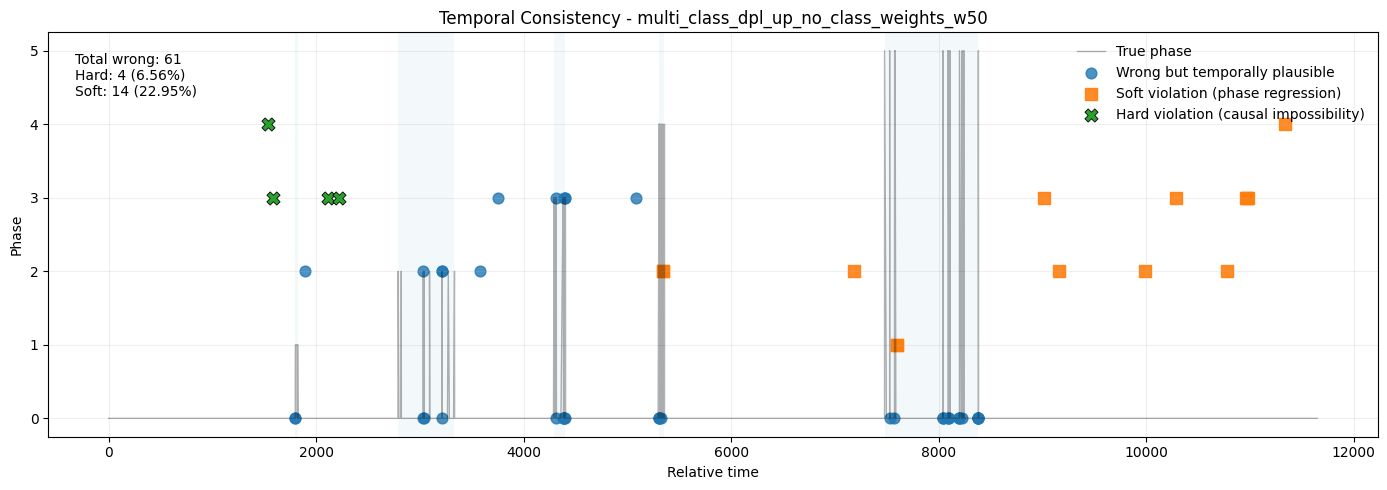

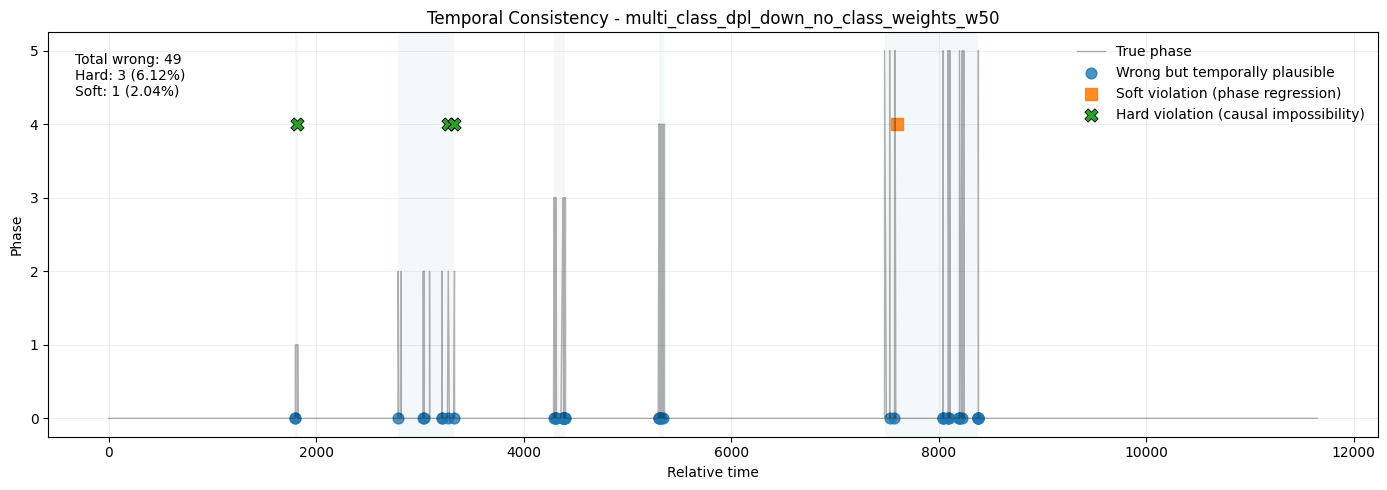

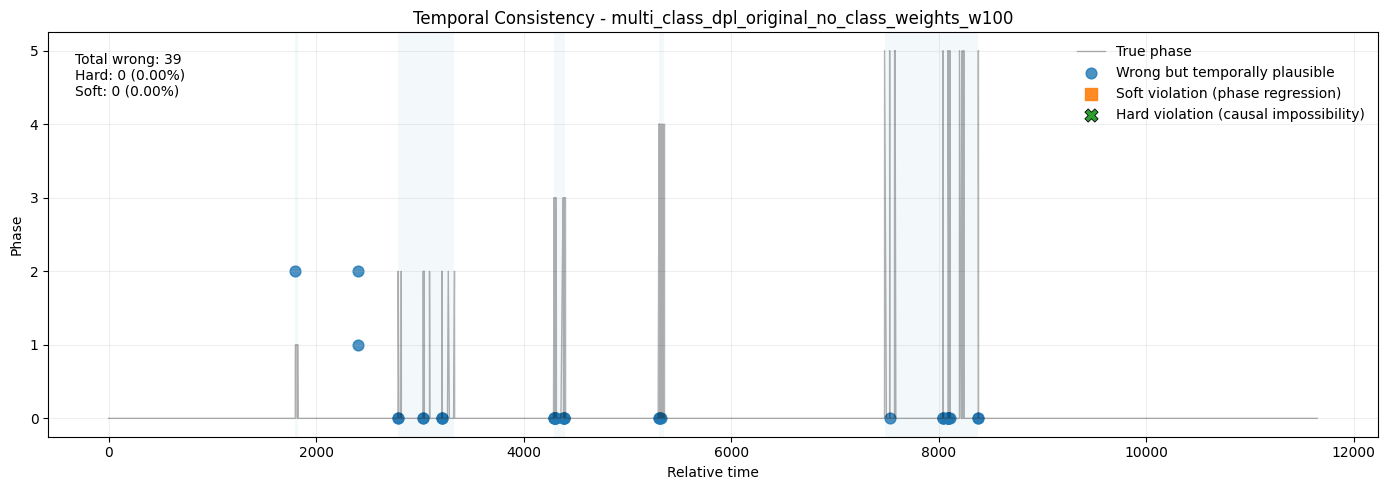

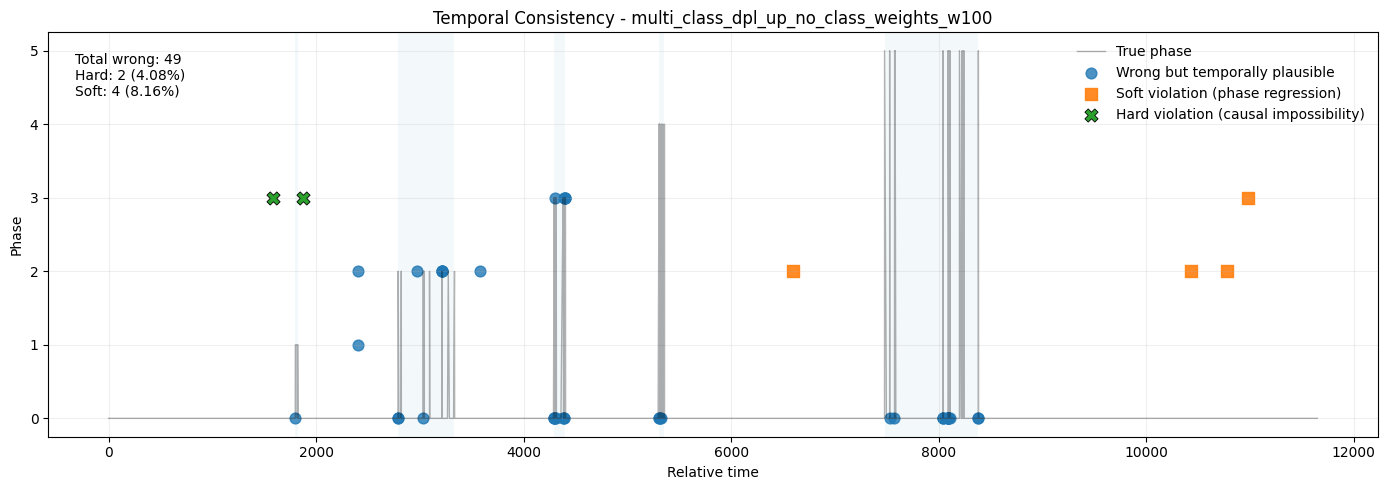

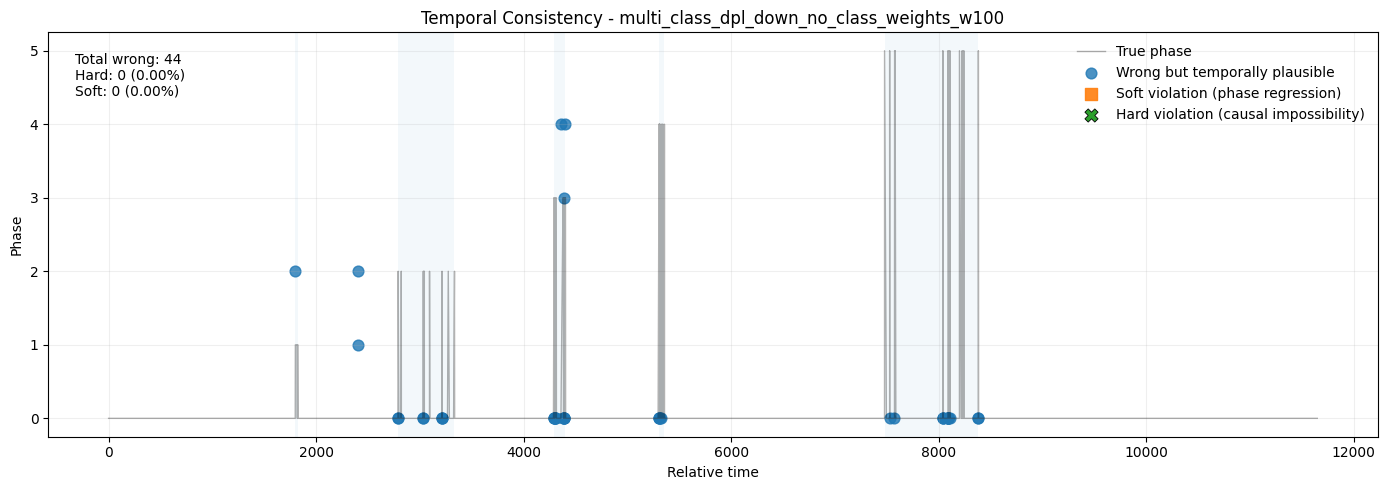

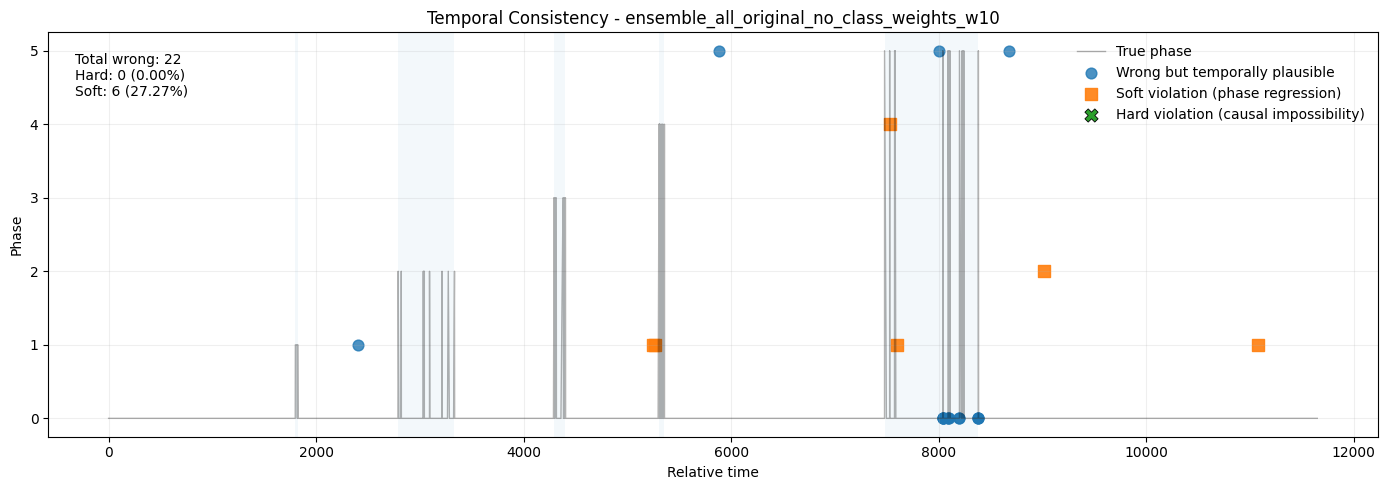

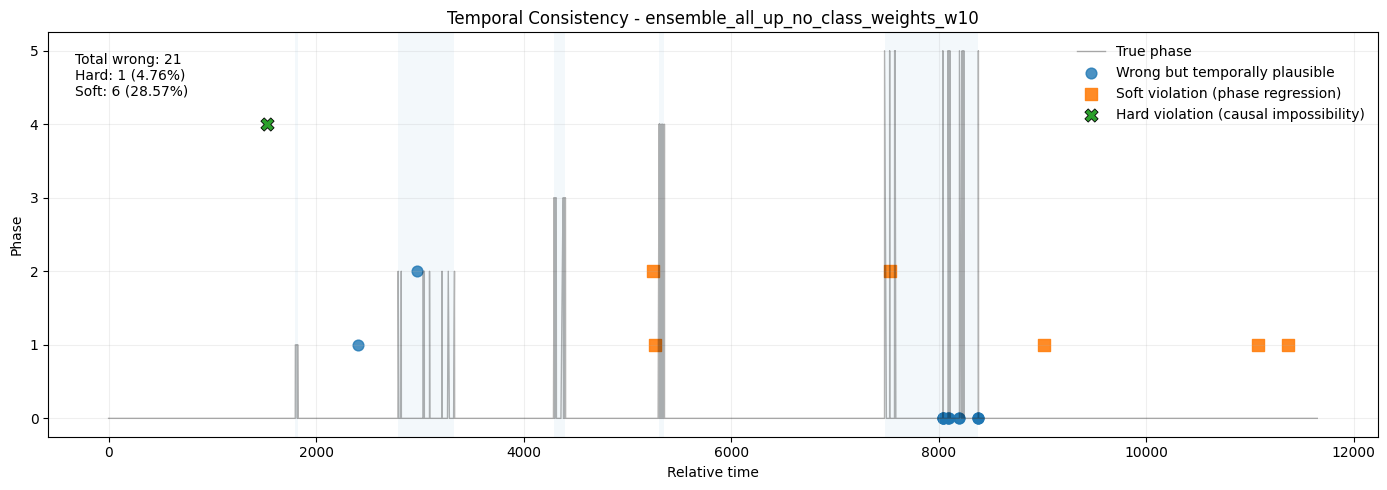

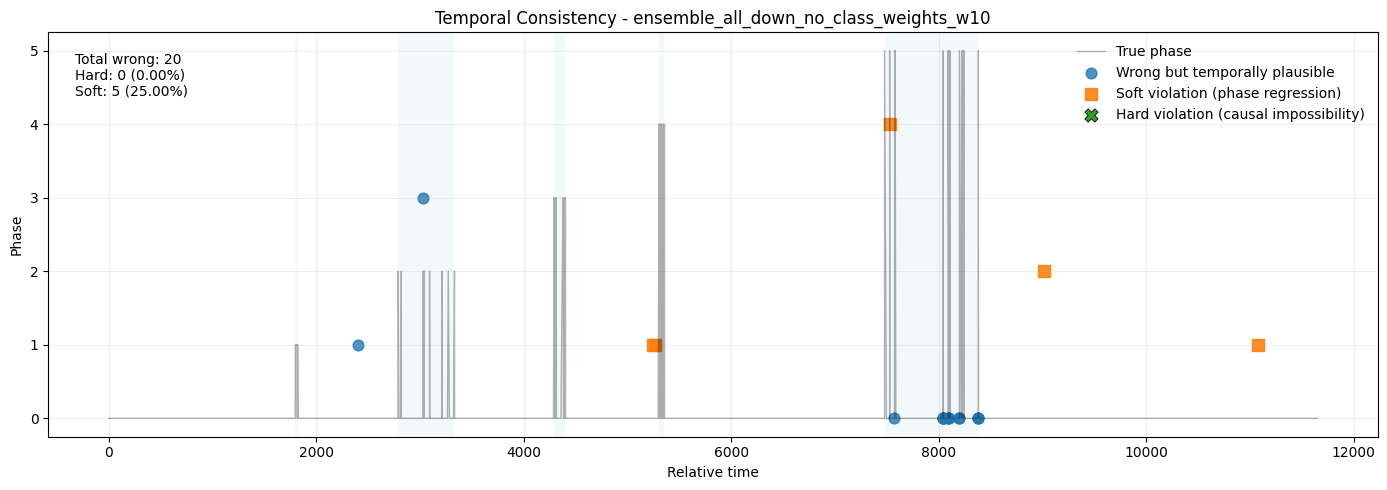

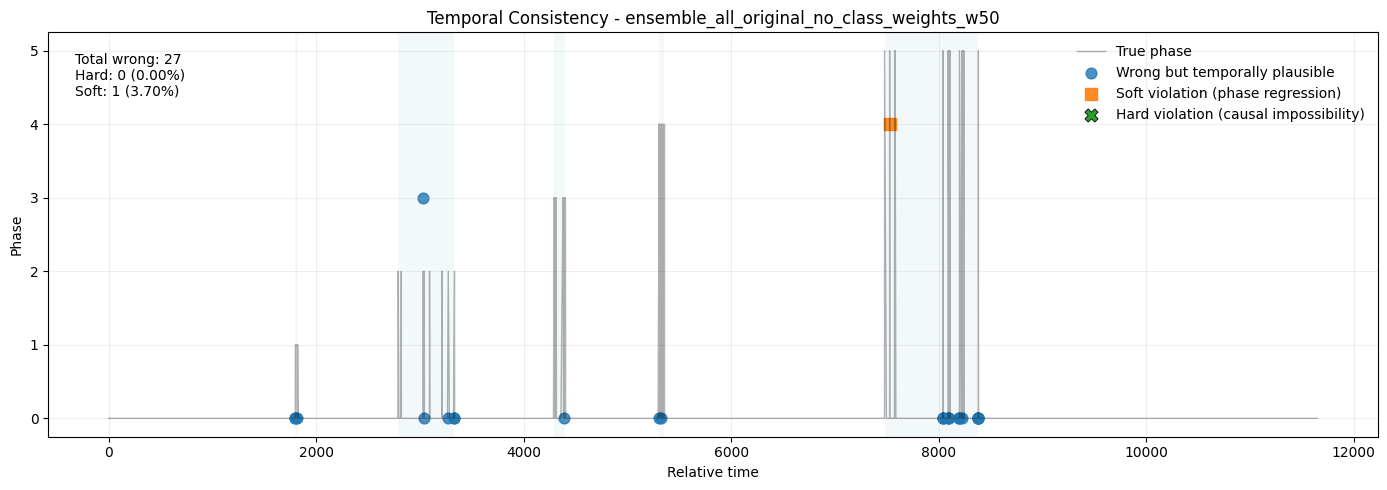

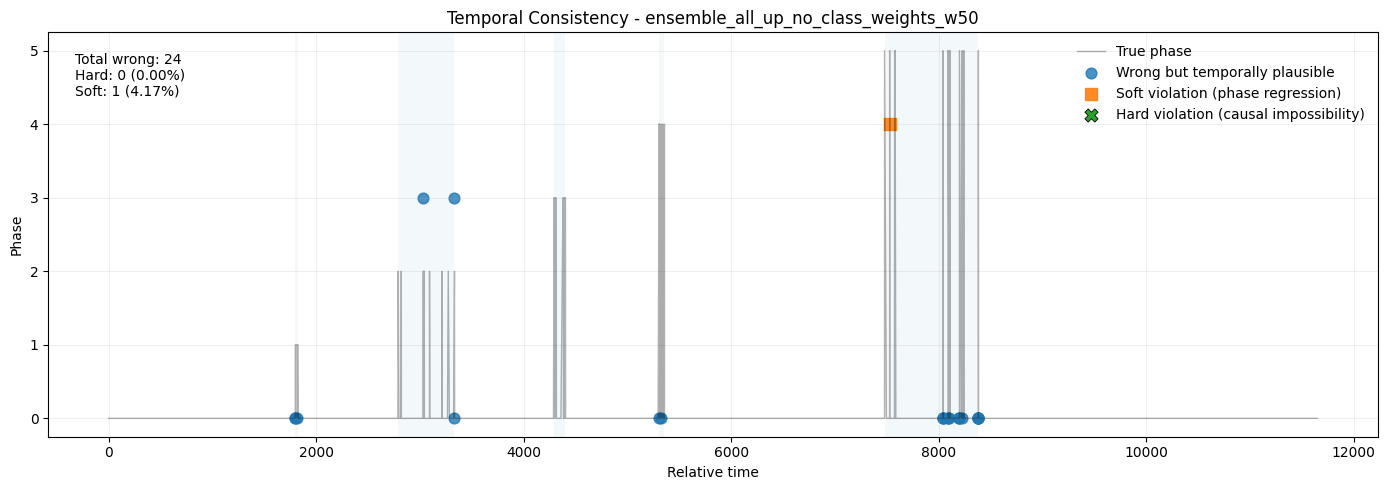

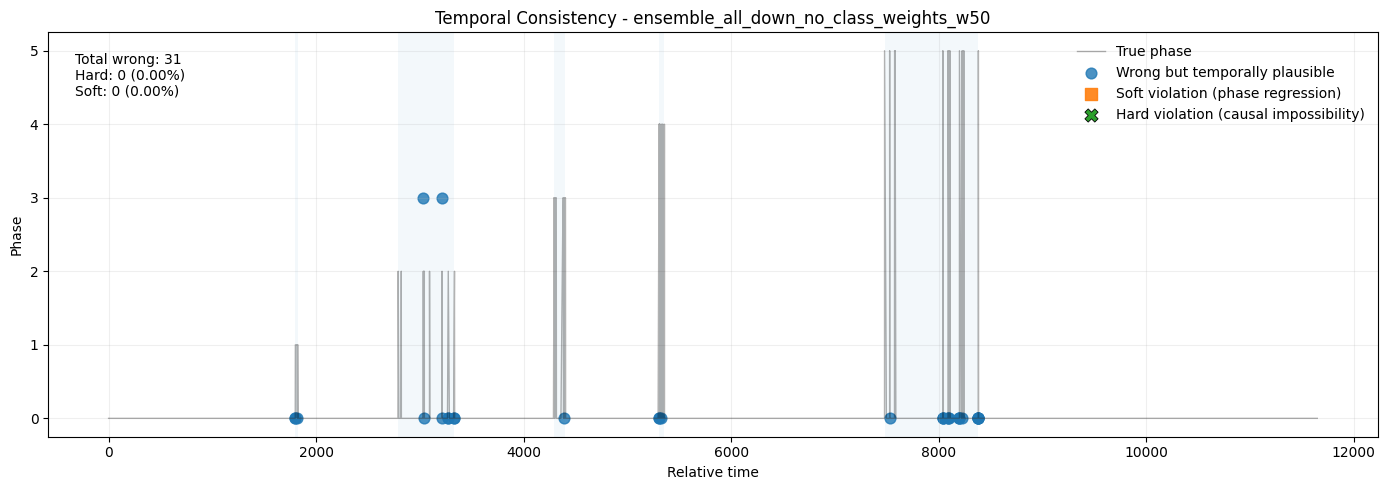

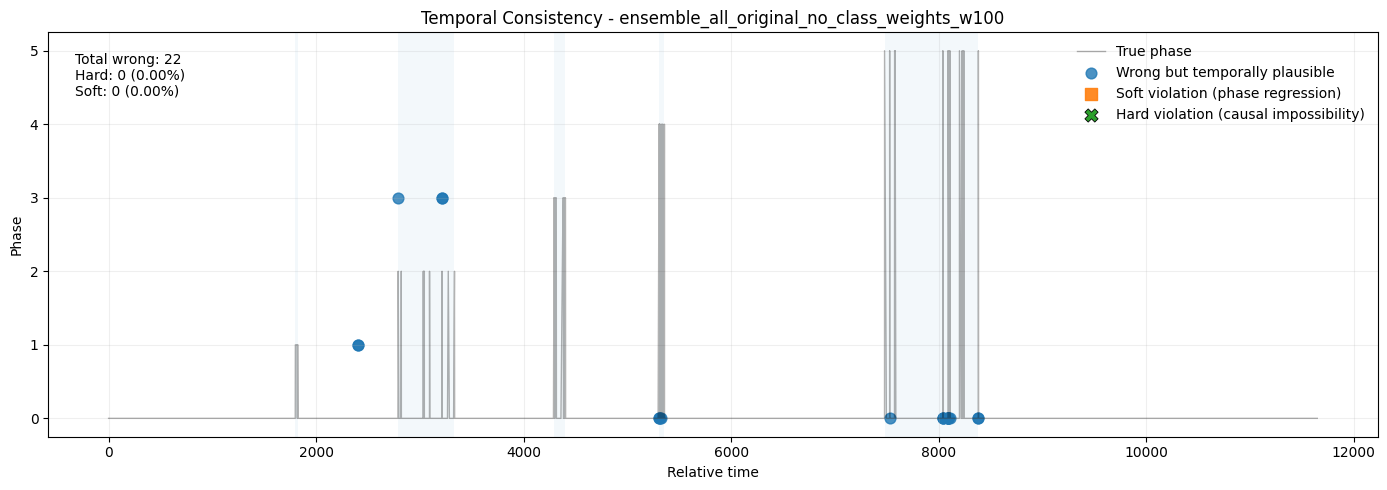

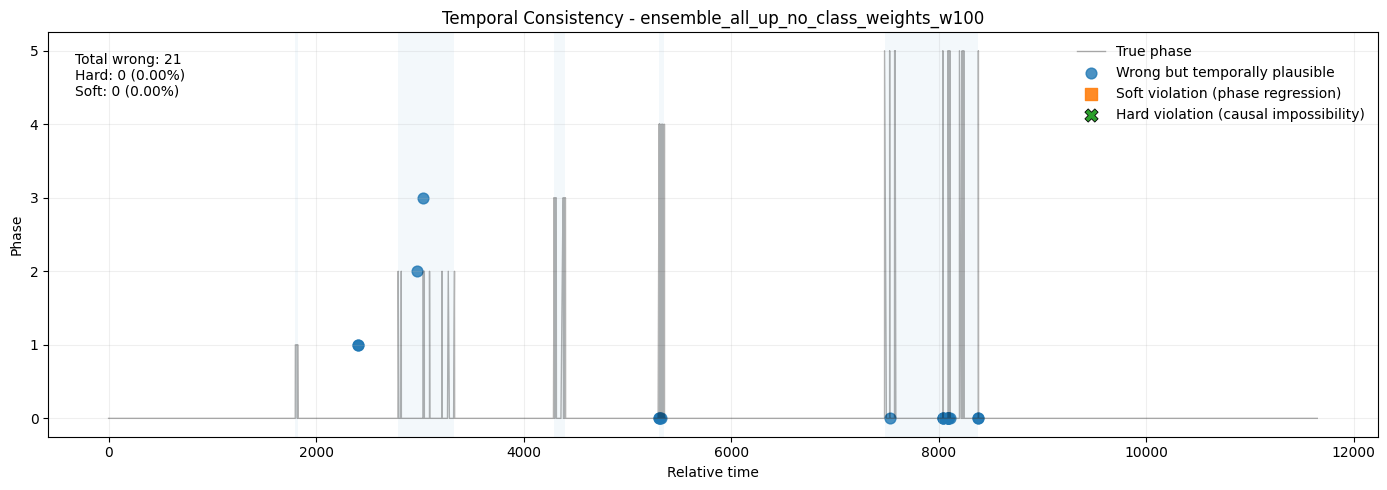

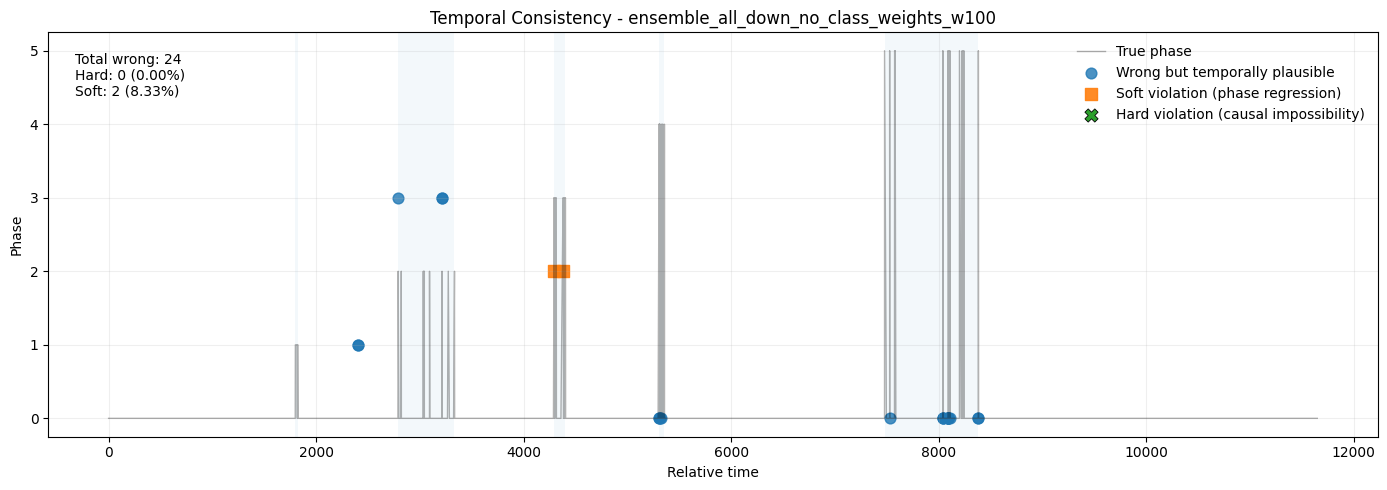

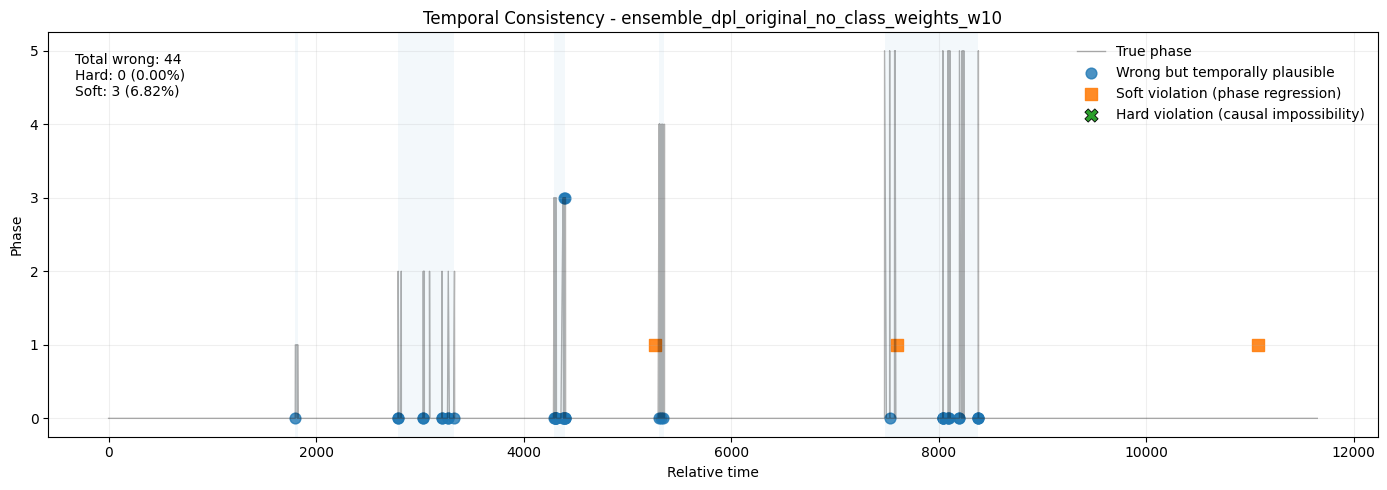

Skipping missing: ../experiments/darpa2000/s1_inside/baselines/ensemble/metrics/ensemble_dpl_up_no_class_weights_w10_metrics.json
Skipping missing: ../experiments/darpa2000/s1_inside/baselines/ensemble/metrics/ensemble_dpl_down_no_class_weights_w10_metrics.json


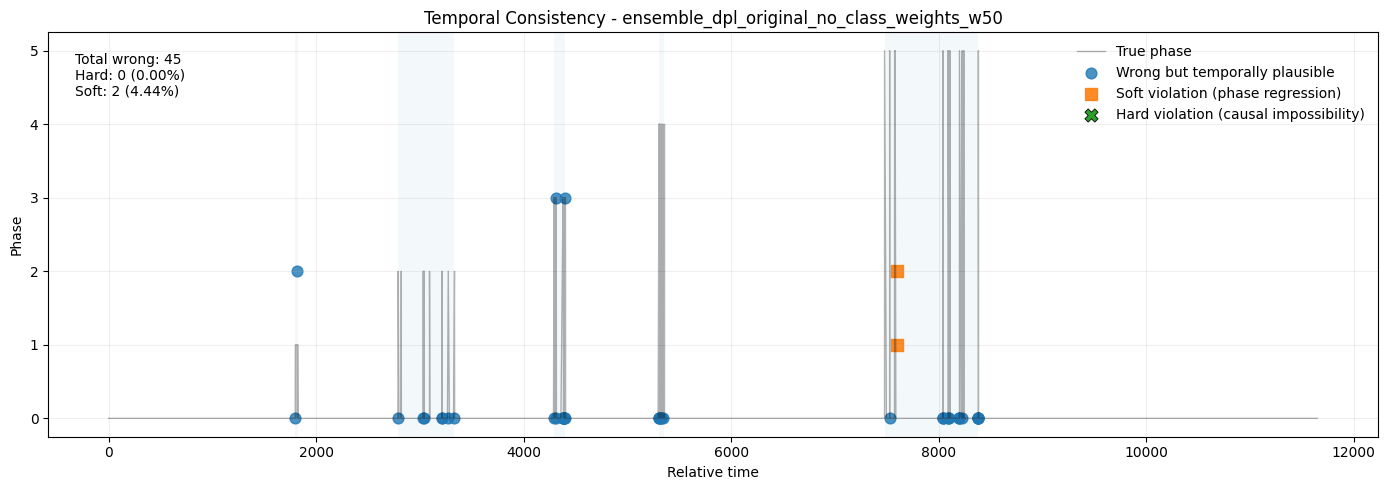

Skipping missing: ../experiments/darpa2000/s1_inside/baselines/ensemble/metrics/ensemble_dpl_up_no_class_weights_w50_metrics.json
Skipping missing: ../experiments/darpa2000/s1_inside/baselines/ensemble/metrics/ensemble_dpl_down_no_class_weights_w50_metrics.json


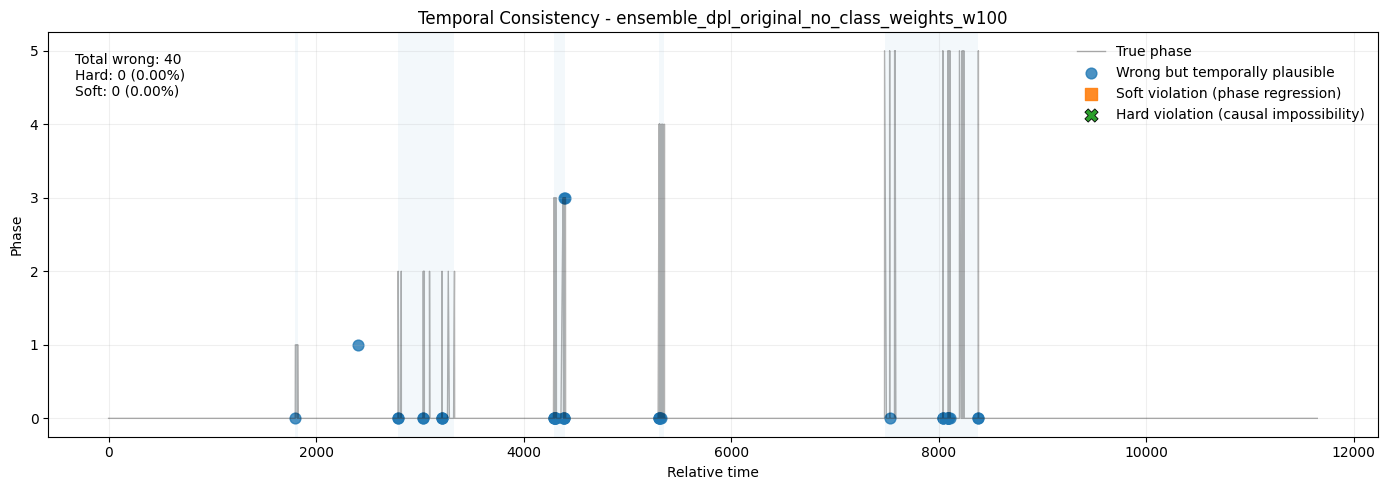

Skipping missing: ../experiments/darpa2000/s1_inside/baselines/ensemble/metrics/ensemble_dpl_up_no_class_weights_w100_metrics.json
Skipping missing: ../experiments/darpa2000/s1_inside/baselines/ensemble/metrics/ensemble_dpl_down_no_class_weights_w100_metrics.json


In [46]:
results = []

for model, features, window_size, dataset_variant, class_weights in product(
    models,
    features_opts,
    window_sizes,
    dataset_variant_opts,
    class_weight_opts
):

    metrics_dir = f"../experiments/{dataset}/{scenario}/baselines/{model}/metrics"
    experiment_name = f"{model}_{features}_{dataset_variant}_{class_weights}_w{window_size}"

    metrics_file = (
        f"{metrics_dir}/"
        f"{experiment_name}_metrics.json"
    )

    if not os.path.exists(metrics_file):
        print(f"Skipping missing: {metrics_file}")
        continue

    with open(metrics_file) as f:
        metrics = json.load(f)

    # --- Load misclassification info ---
    real_flow_indices = metrics["real_flow_indices"]
    mis_y_pred = metrics["y_pred"]
    mis_y_true = metrics["y_true"]

    mis_df = df.iloc[real_flow_indices].copy()
    mis_df["y_true"] = mis_y_true
    mis_df["y_pred"] = mis_y_pred

    # --- Compute violation categories ---
    wrong, hard, soft, plausible = mis_metrics(mis_df, phase_start)

    total_wrong = len(wrong)
    hard_rate = len(hard) / total_wrong if total_wrong > 0 else 0
    soft_rate = len(soft) / total_wrong if total_wrong > 0 else 0

    # --- Collect everything ---
    results.append({
        "model": f"{experiment_name}",
        "accuracy": metrics["accuracy"],
        "precision" : metrics["precision"],
        "recall" : metrics["recall"], 
        "f1": metrics["f1"],
        "total_wrong": total_wrong,
        "hard_violations": len(hard),
        "soft_violations": len(soft),
        "hard_rate": hard_rate,
        "soft_rate": soft_rate,
    })

    # Create plots
    out_dir = Path(f"../reports/baselines/{model}")
    plot_mis_predictions(df, phase_bounds, plausible, soft, hard, total_wrong, soft_rate, hard_rate, experiment_name, out_dir)

## Metrics for All Models

In [47]:
results_df = pd.DataFrame(results)

results_df

,model,accuracy,precision,recall,f1,total_wrong,hard_violations,soft_violations,hard_rate,soft_rate
0,multi_class_all_original_no_class_weights_w10,0.999523,0.826585,0.915230,0.860640,24,0,9,0.000000,0.375000
1,multi_class_all_up_no_class_weights_w10,0.999563,0.878264,0.969449,0.918665,22,1,5,0.045455,0.227273
2,multi_class_all_down_no_class_weights_w10,0.999523,0.899140,0.846794,0.858906,24,0,4,0.000000,0.166667
3,multi_class_all_original_no_class_weights_w50,0.999424,0.949793,0.748256,0.799626,29,0,1,0.000000,0.034483
4,multi_class_all_up_no_class_weights_w50,0.999483,0.929002,0.873555,0.893298,26,0,4,0.000000,0.153846
5,multi_class_all_down_no_class_weights_w50,0.999284,0.620952,0.661924,0.621784,36,0,9,0.000000,0.250000
6,multi_class_all_original_no_class_weights_w100,0.999483,0.840150,0.778019,0.784885,26,0,0,0.000000,0.000000
7,multi_class_all_up_no_class_weights_w100,0.999622,0.979023,0.907651,0.933597,19,0,0,0.000000,0.000000
8,multi_class_all_down_no_class_weights_w100,0.999403,0.792499,0.719820,0.743189,30,0,5,0.000000,0.166667
9,multi_class_dpl_original_no_class_weights_w10,0.999066,0.721880,0.609974,0.647142,47,1,0,0.021277,0.000000


In [48]:
results_df["temporal_score"] = (
    results_df["f1"]
    - 0.5 * results_df["hard_rate"]
    - 0.2 * results_df["soft_rate"]
)

In [49]:
results_df_sorted_f1 = results_df.sort_values("f1", ascending=False)

# Save metrics to file
results_df_sorted_f1.to_csv(
    f"../reports/baselines/temporal_consistency_summary.csv",
    index=False
)

In [50]:
results_df_sorted_f1.head()

,model,accuracy,precision,recall,f1,total_wrong,hard_violations,soft_violations,hard_rate,soft_rate,temporal_score
18,ensemble_all_original_no_class_weights_w10,0.999563,0.898285,0.999855,0.940305,22,0,6,0.000000,0.272727,0.885760
7,multi_class_all_up_no_class_weights_w100,0.999622,0.979023,0.907651,0.933597,19,0,0,0.000000,0.000000,0.933597
20,ensemble_all_down_no_class_weights_w10,0.999603,0.893878,0.981362,0.931178,20,0,5,0.000000,0.250000,0.881178
19,ensemble_all_up_no_class_weights_w10,0.999583,0.873302,0.999862,0.925280,21,1,6,0.047619,0.285714,0.844328
1,multi_class_all_up_no_class_weights_w10,0.999563,0.878264,0.969449,0.918665,22,1,5,0.045455,0.227273,0.850483


In [51]:
results_df_sorted_temp = results_df.sort_values("temporal_score", ascending=False)

results_df_sorted_temp.head()

,model,accuracy,precision,recall,f1,total_wrong,hard_violations,soft_violations,hard_rate,soft_rate,temporal_score
7,multi_class_all_up_no_class_weights_w100,0.999622,0.979023,0.907651,0.933597,19,0,0,0.0,0.000000,0.933597
25,ensemble_all_up_no_class_weights_w100,0.999582,0.936901,0.886146,0.890432,21,0,0,0.0,0.000000,0.890432
18,ensemble_all_original_no_class_weights_w10,0.999563,0.898285,0.999855,0.940305,22,0,6,0.0,0.272727,0.885760
20,ensemble_all_down_no_class_weights_w10,0.999603,0.893878,0.981362,0.931178,20,0,5,0.0,0.250000,0.881178
22,ensemble_all_up_no_class_weights_w50,0.999523,0.951221,0.834235,0.878503,24,0,1,0.0,0.041667,0.870170


## Analyze Specific Model

In [52]:
# Hyperparameters for best-performing model
model = "multi_class"
features = "all"
dataset_variant = "up"
weights = "no_class_weights"
window_size = 10

In [53]:
processed_dir = f"../data/processed/{dataset}/{scenario}/windowed"
metrics_dir = f"../experiments/{dataset}/{scenario}/baselines/{model}/metrics"

exp_name = f"{model}_{features}_{dataset_variant}_{weights}_w{window_size}"
metrics_file = f"{metrics_dir}/{exp_name}_metrics.json"

In [54]:
with open(metrics_file) as f:
    metrics = json.load(f)

misclassified_indices = metrics["misclassified_indices"]
real_flow_indices = metrics["real_flow_indices"]
mis_y_pred = metrics["y_pred"]
mis_y_true = metrics["y_true"]

mis_df = df.iloc[real_flow_indices].copy()
mis_df["y_true"] = mis_y_true
mis_df["y_pred"] = mis_y_pred


In [55]:
wrong, hard, soft, plausible = mis_metrics(mis_df, phase_start)

total_wrong = len(wrong)

hard_rate = len(hard) / total_wrong if total_wrong > 0 else 0
soft_rate = len(soft) / total_wrong if total_wrong > 0 else 0

print(f"Total wrong: {total_wrong}")
print(f"Hard violations: {len(hard)} ({hard_rate:.2%})")
print(f"Soft violations: {len(soft)} ({soft_rate:.2%})")

Total wrong: 22
Hard violations: 1 (4.55%)
Soft violations: 5 (22.73%)


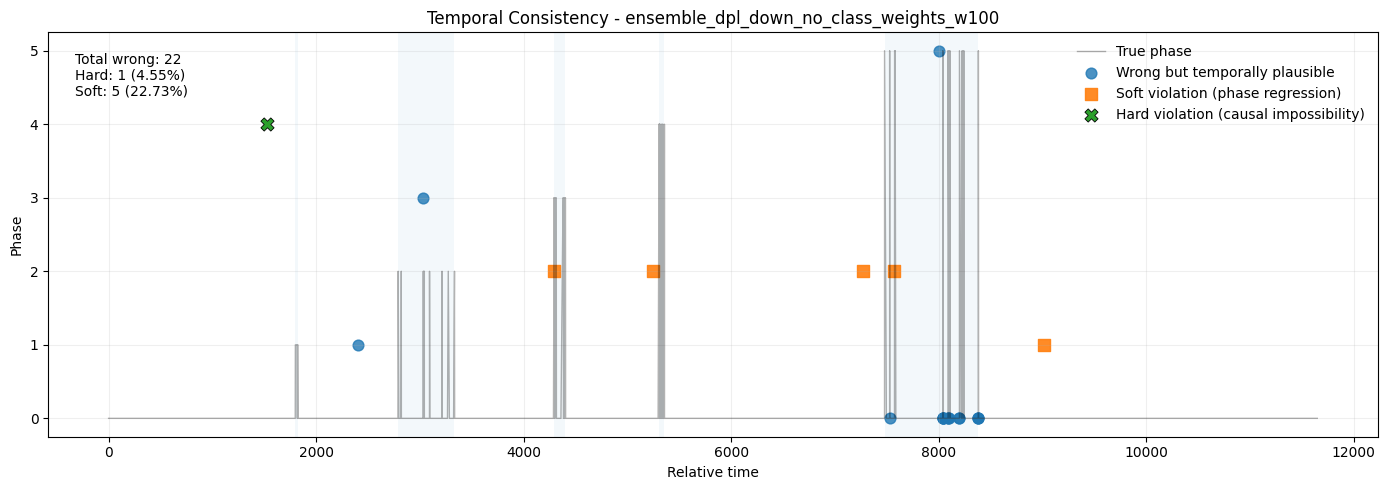

In [56]:
out_dir = ""
plot_mis_predictions(df, phase_bounds, plausible, soft, hard, total_wrong, soft_rate, hard_rate, experiment_name, out_dir, save_plot=False)

In [57]:
mis_only = mis_df[mis_df["y_true"] != mis_df["y_pred"]]

pd.crosstab(
    mis_only["y_true"],
    mis_only["y_pred"],
)

y_pred,0,1,2,3,4,5
y_true,,,,,,
0,0,2,2,0,1,1
2,0,0,0,1,0,0
3,0,0,1,0,0,0
5,13,0,1,0,0,0
